In [2]:
# Importing packages
import numpy as np # for working with array objects (objects that hold more than one value)
import pandas as pd # for working with data sets
from scipy.optimize import minimize # mathematical optimization package
import matplotlib.pyplot as plt # to make plots

In [3]:
# Logit probability + model solver

def sigmoid(z):
    """
    Logistic (sigmoid) transformation.

    Converts the systematic utility difference z = ΔV into a probability
    between 0 and 1 according to the logit formula

        p = 1 / (1 + exp(-z))

    In the model, this represents the probability that a firm hires
    a non-resident worker given the profit difference ΔV.
    """

    # clip extremely large or small values to avoid numerical overflow
    # when computing the exponential function
    z = np.clip(z, -35, 35)

    # apply the logistic transformation
    # this maps any real value into the interval (0,1)
    return 1.0 / (1.0 + np.exp(-z))

def solve_model(params, df):
    """
    Compute predicted hiring probabilities from the structural model.

    params = (alpha (intercept), beta_w (wage ratio), beta_f (LM tightness), beta_b (border regime), beta_x (observable char.))
        Model parameters corresponding to the empirical specification:
        ΔV = alpha + beta_w ln(w_ratio) + beta_f ln(theta) + beta_b B + beta_x X

    df must contain the columns:
        ln_w_ratio : log wage ratio between non-resident and resident workers
        ln_theta   : log labor market tightness
        B          : border regime indicator
        X          : firm characteristic

    Returns:
        A copy of df with an additional column 'p' containing the predicted
        probability that the firm hires a non-resident worker.
    """

    # unpack parameter vector
    alpha, beta_w, beta_f, beta_b, beta_x = params

    # construct the systematic profit difference ΔV_{n,t}
    # this corresponds to the empirical specification derived in the model
    deltav = (
        alpha
        + beta_w * df["ln_w_ratio"].to_numpy()   # effect of relative wage cost
        + beta_f * df["ln_theta"].to_numpy()     # effect of labor market tightness
        + beta_b * df["B"].to_numpy()            # effect of border/mobility regime
        + beta_x * df["X"].to_numpy()            # effect of firm characteristics
    )

    # create a copy of the dataset so the original data are not modified
    out = df.copy()

    # convert the systematic utility difference into a hiring probability
    # using the logistic transformation implied by the logit model
    out["p"] = sigmoid(deltav)

    # return dataset including predicted probabilities
    return out

In [4]:
# Simulating synthetic panel data

def simulate_data(N=2000, T=24, true_params=None, seed=221):
    """
    Generate simulated panel data consistent with the structural model.

    N : number of firms
    T : number of time periods
    true_params : structural parameters used in the data generating process
                  (alpha, beta_w, beta_f, beta_b, beta_x)
    seed : random seed for reproducibility

    Returns a dataframe with N x T observations and columns:
        ID         : firm identifier
        t          : time period
        X          : firm characteristic
        ln_theta   : log labor market tightness
        B          : border regime indicator
        ln_w_ratio : log wage ratio (NR vs R)
        y          : simulated hiring decision (0/1)
    """

    # if no parameter vector is provided, use default "true" parameters
    # these correspond to (alpha, beta_w, beta_f, beta_b, beta_x)
    if true_params is None:
        true_params = (-0.2, -1.0, 0.8, -0.6, 0.4)

    # initialize random number generator for reproducibility
    rng = np.random.default_rng(seed)

    # ------------------------------------------------------------
    # 1. Firm-level heterogeneity
    # ------------------------------------------------------------
    # Each firm receives a unique ID and a firm-specific characteristic X_n
    # capturing heterogeneity in hiring behavior
    firm = pd.DataFrame({
        "ID": np.arange(1, N + 1),
        "X": rng.normal(0, 1, size=N) # draws from a normal distribution
    })

    # ------------------------------------------------------------
    # 2. Time dimension
    # ------------------------------------------------------------
    # Create time index for the panel dataset
    t = np.arange(1, T + 1)

    # ------------------------------------------------------------
    # 3. Labor market tightness
    # ------------------------------------------------------------
    # Generate log tightness with cyclical variation (business-cycle pattern)
    # plus random shocks
    ln_theta_t = (
        0.5 * np.sin(2 * np.pi * t / T) # creating a wave pattern using sin
        + rng.normal(0, 0.3, size=T)
    )

    # standardize series (mean = 0, variance = 1) for numerical stability
    # by rescaling. ddof=0 is the population standard deviation.
    ln_theta_t = (ln_theta_t - ln_theta_t.mean()) / ln_theta_t.std(ddof=0)

    # ------------------------------------------------------------
    # 4. Policy regime variable
    # ------------------------------------------------------------
    # Border regime dummy:
    # B_t = 0 in first half of sample, 1 in second half
    # This mimics a policy shift affecting non-resident workers
    B_t = (t > int(round(T / 2))).astype(int)

    # ------------------------------------------------------------
    # 5. Relative wages
    # ------------------------------------------------------------
    # Generate log wage ratio between NR and R workers.
    # Wages are allowed to depend partly on labor market tightness,
    # creating correlation between wages and labor market conditions.
    ln_w_ratio_t = (
        0.2 * ln_theta_t
        + rng.normal(0, 0.2, size=T)
    )

    # combine time-varying variables into a dataframe
    time = pd.DataFrame({
        "t": t,
        "ln_theta": ln_theta_t,
        "B": B_t,
        "ln_w_ratio": ln_w_ratio_t
    })

    # ------------------------------------------------------------
    # 6. Construct panel dataset
    # ------------------------------------------------------------
    # The dataset has N x T observations
    df = firm.merge(time, how="cross")

    # ------------------------------------------------------------
    # 7. Compute hiring probabilities from the structural model
    # ------------------------------------------------------------
    df = solve_model(true_params, df)

    # ------------------------------------------------------------
    # 8. Simulate observed hiring decisions
    # ------------------------------------------------------------
    # Each firm-period observation draws a binary outcome
    # from a Bernoulli distribution with probability p_{n,t}
    df["y"] = rng.binomial(
        n=1, # outcome is either 0 or 1 (one trial)
        p=df["p"].to_numpy(), # probability of success using p
        size=len(df) # one draw for every N x T
    )

    return df

In [5]:
# Maximum likelihood estimation using BFGS
# This block contains:
# 1. the negative log-likelihood function
# 2. the estimator that minimizes it and returns parameter estimates + standard errors

def neg_loglik(params, df):
    """
    Compute the negative log-likelihood for the binary logit model.

    params : alpha, beta_w, beta_f, beta_b, beta_x
    df     : dataframe containing covariates and observed hiring outcome y

    Returns:
        Negative sample log-likelihood evaluated at params.
    """

    # compute predicted probabilities p_{n,t} from the structural model
    dd = solve_model(params, df)
    p = dd["p"].to_numpy() # selects the column p and convets it to an array

    # numerical safety:
    # avoid probabilities being exactly 0 or 1, since log(0) is undefined
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps) # force p to stay within range

    # observed binary hiring decision
    y = df["y"].to_numpy()

    # Bernoulli log-likelihood:
    # log L = sum[ y log(p) + (1-y) log(1-p) ]
    # return the negative because scipy.optimize.minimize solves minimization problems
    return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))


def estimate_mle(df, start=None): # no starting values
    """
    Estimate model parameters by maximum likelihood using the BFGS algorithm.

    df    : dataframe with simulated or observed data
    start : optional starting values for the optimizer

    Returns a dictionary containing:
        par     : estimated parameters
        se      : approximate standard errors
        value   : minimized value of the negative log-likelihood
        conv    : convergence indicator (0 = success, 1 = failure)
        success : optimizer success flag
        message : optimizer diagnostic message
        cov     : approximate covariance matrix
    """

    # if no starting values are provided, start from zeros
    if start is None:
        start = np.zeros(5) # alpha and betas start at 0 

    # minimize the negative log-likelihood using BFGS
    # which is a quasi-Newton method that iteratively approximates the Hessian
    res = minimize(
        fun=neg_loglik,
        x0=np.array(start, dtype=float), # starting at [0, 0, 0, 0, 0] floating point numbers
        args=(df,), # passing arguments to the likelihood funciton
        method="BFGS", # choose numerical algorithm
        options={"disp": False}
    )

    # approximate covariance matrix from the inverse Hessian returned by BFGS
    # standard errors are the square roots of the diagonal elements
    try:
        cov = np.array(res.hess_inv) # returning the covariance matrix
        se = np.sqrt(np.diag(cov)) # extract diagonal elements and take square roots for SE
    except Exception:
        # if the Hessian-based calculation fails, return missing values
        cov = np.full((len(start), len(start)), np.nan)
        se = np.full(len(start), np.nan)

    # package estimation results in a dictionary
    return {
        "par": res.x,                      # estimated parameter vector
        "se": se,                          # approximate standard errors
        "value": res.fun,                  # minimized negative log-likelihood
        "conv": int(res.success == False), # 0 if success, 1 if failure (R-style convention)
        "success": res.success,            # Python optimizer convergence flag
        "message": res.message,            # diagnostic optimizer message
        "cov": cov                         # approximate covariance matrix
    }

In [6]:
# Counterfactual function (changes labor market tightness or border regime)

def counterfactual(est_params, df, theta_multiplier=1.0, set_B=None):
    """
    Compute the average predicted hiring probability under a counterfactual scenario.

    est_params : estimated parameter vector from the MLE
    df         : original dataset
    theta_multiplier : factor by which labor market tightness is scaled
                       (e.g. 1.10 means tightness increases by 10%)
    set_B      : optional override for the regime variable B
                 (e.g. force open or closed border scenario)

    Returns:
        Average predicted probability of hiring a non-resident worker.
    """

    # create a copy of the data so the original dataset remains unchanged
    cf = df.copy()

    # modify labor market tightness
    # since the model uses ln(theta), multiplying theta by m implies
    # ln(theta_cf) = ln(theta) + ln(m)
    cf["ln_theta"] = cf["ln_theta"] + np.log(theta_multiplier)

    # optionally override the border regime variable
    # this allows simulation of alternative policy regimes
    if set_B is not None:
        cf["B"] = int(set_B)

    # recompute predicted hiring probabilities using the estimated parameters
    cf = solve_model(est_params, cf)

    # return the average predicted hiring probability across all observations
    return cf["p"].mean()

In [7]:
# Running the code

# ------------------------------------------------------------
# Run the full simulation–estimation–counterfactual workflow
# ------------------------------------------------------------

# true structural parameters used in the data-generating process
# (alpha, beta_w, beta_f, beta_b, beta_x)
true_params = (-0.2, -1.0, 0.8, -0.6, 0.4)

# simulate a panel dataset with 3000 firms observed over 24 periods
# using the structural model defined earlier
dat = simulate_data(N=3000, T=24, true_params=true_params, seed=221)

# estimate the model parameters by maximum likelihood
est = estimate_mle(dat)

# print estimation results and compare them to the true parameters
print("Estimated params:", est["par"])
print("True params     :", true_params)
print("SEs             :", est["se"])
print("Converged?      :", est["success"])
print("Message         :", est["message"])

# ------------------------------------------------------------
# Compute predicted hiring probabilities
# ------------------------------------------------------------

# baseline prediction: average probability of hiring a non-resident worker
# under the simulated data environment
base_share = solve_model(est["par"], dat)["p"].mean()

# counterfactual 1: increase labor market tightness by 10%
# (theta_cf = 1.10 * theta)
cf_tight10 = counterfactual(est["par"], dat, theta_multiplier=1.10)

# counterfactual 2: open-border regime (set B = 0 for all observations)
cf_openborder = counterfactual(est["par"], dat, set_B=0)

# counterfactual 3: closed-border regime (set B = 1 for all observations)
cf_closedborder = counterfactual(est["par"], dat, set_B=1)

# print average predicted hiring probabilities for each scenario
print("\nCounterfactual means (predicted p):")
print({
       "base": base_share,
       "tight10": cf_tight10,
       "openborder": cf_openborder,
       "closedborder": cf_closedborder
      })

Estimated params: [-0.20807959 -1.04115876  0.8066607  -0.58224876  0.38727585]
True params     : (-0.2, -1.0, 0.8, -0.6, 0.4)
SEs             : [0.01038108 0.01651533 0.00979073 0.01479628 0.01345766]
Converged?      : False
Message         : Desired error not necessarily achieved due to precision loss.

Counterfactual means (predicted p):
{'base': np.float64(0.38862500571375574), 'tight10': np.float64(0.404212810622989), 'openborder': np.float64(0.4452304410977639), 'closedborder': np.float64(0.3220698172101605)}


In [ ]:
# Monte Carlo loop
# Repeats the full workflow many times:
# simulate data -> estimate parameters -> compute counterfactual effects

def mc(R=200, N=2000, T=24, true_params=None, seed0=1000, start=None):
    """
    Run a Monte Carlo experiment for the structural model.

    R           : number of Monte Carlo replications
    N           : number of firms in each simulated dataset
    T           : number of time periods in each simulated dataset
    true_params : true structural parameters used in the data-generating process
    seed0       : initial seed; each replication uses seed0 + r
    start       : optional starting values for the MLE optimizer

    Returns:
        estimates : dataframe containing estimated parameters from each replication
        effects   : dataframe containing counterfactual effects from each replication
    """

    # if no parameter vector is provided, use the default "true" parameters
    if true_params is None:
        true_params = (-0.2, -1.0, 0.8, -0.6, 0.4)

    # number of parameters to estimate
    k = len(true_params)

    # storage matrix for parameter estimates from each replication
    # rows = replications, columns = parameters
    out = np.full((R, k), np.nan)

    # storage for counterfactual effects from each replication
    # tight10 = effect of increasing labor market tightness by 10%
    # border  = effect of moving from open border (B=0) to closed border (B=1)
    effects = pd.DataFrame({
        "tight10": np.full(R, np.nan),
        "border": np.full(R, np.nan)
    })

    # ------------------------------------------------------------
    # Monte Carlo loop
    # ------------------------------------------------------------
    for r in range(R):
        # simulate one dataset using a different seed in each replication
        dat_r = simulate_data(
            N=N,
            T=T,
            true_params=true_params,
            seed=seed0 + r
        )

        # estimate parameters by maximum likelihood on the simulated dataset
        est_r = estimate_mle(dat_r, start=start)

        # store estimated parameter vector
        out[r, :] = est_r["par"]

        # --------------------------------------------------------
        # Compute baseline and counterfactual predicted probabilities
        # --------------------------------------------------------

        # baseline average predicted hiring probability
        base = solve_model(est_r["par"], dat_r)["p"].mean()

        # counterfactual: increase labor market tightness by 10%
        tight10 = counterfactual(est_r["par"], dat_r, theta_multiplier=1.10)

        # counterfactual: open-border environment
        openb = counterfactual(est_r["par"], dat_r, set_B=0)

        # counterfactual: closed-border environment
        closedb = counterfactual(est_r["par"], dat_r, set_B=1)

        # store counterfactual effects relative to the baseline / open-border case
        effects.loc[r, "tight10"] = tight10 - base
        effects.loc[r, "border"] = closedb - openb

    # label parameter columns
    cols = ["alpha", "beta_w", "beta_f", "beta_b", "beta_x"]

    # convert stored estimates into a dataframe for easier summary/statistics
    est_df = pd.DataFrame(out, columns=cols)

    return {
        "estimates": est_df,
        "effects": effects
    }


# run Monte Carlo experiment with 200 replications
mc_res = mc(R=200, N=2000, T=24, true_params=true_params)

# summary statistics for the estimated parameters across replications
mc_res["estimates"].describe()

,alpha,beta_w,beta_f,beta_b,beta_x
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,-0.199611,-1.002783,0.799972,-0.599306,0.400503
std,0.016134,0.053615,0.019181,0.028568,0.009871
min,-0.247361,-1.133146,0.754388,-0.676311,0.378240
25%,-0.210880,-1.041938,0.786247,-0.620256,0.393997
50%,-0.198885,-1.006506,0.801049,-0.599110,0.400958
75%,-0.189019,-0.960523,0.812287,-0.581937,0.406801
max,-0.160309,-0.869245,0.854196,-0.514252,0.432183


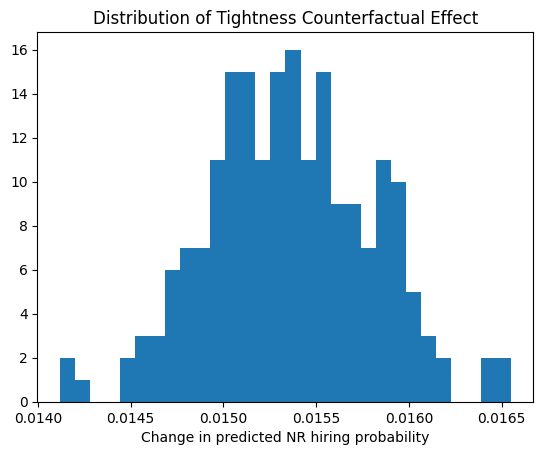

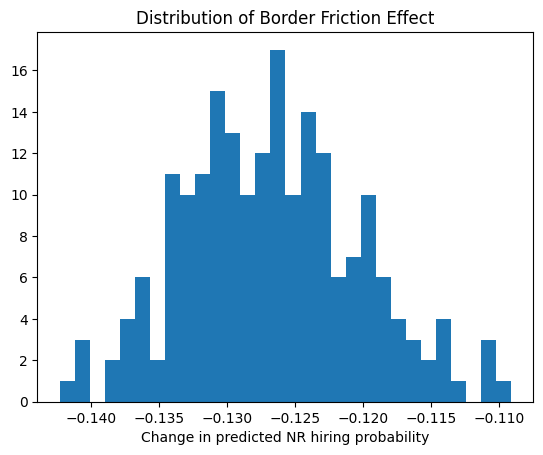

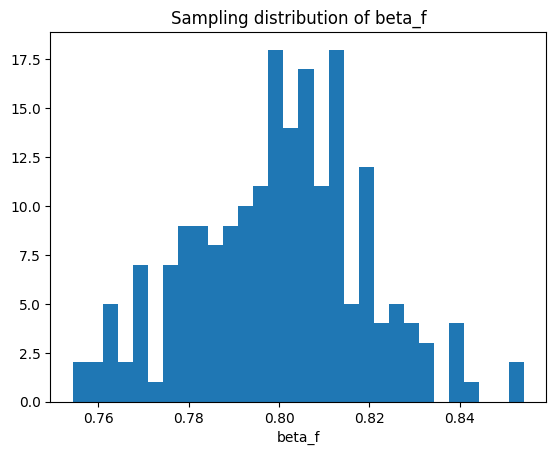

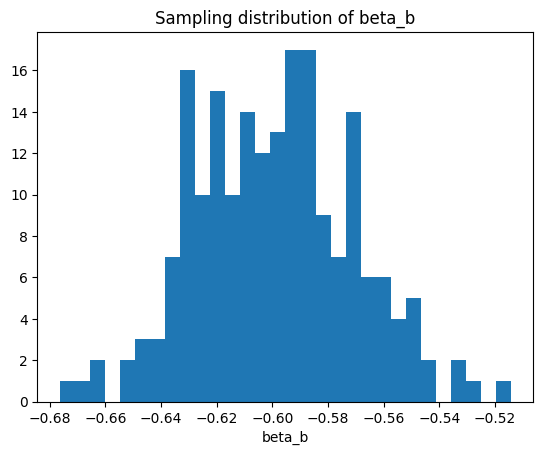

Bias (mean(est) - true): {'alpha': np.float64(0.0003888714982487884), 'beta_w': np.float64(-0.002782704240365419), 'beta_f': np.float64(-2.8366673937130216e-05), 'beta_b': np.float64(0.0006940608947639815), 'beta_x': np.float64(0.0005034788460236972)}


In [12]:
# Plots
plt.figure()
plt.hist(mc_res["effects"]["tight10"].dropna(), bins=30)
plt.title("Distribution of Tightness Counterfactual Effect")
plt.xlabel("Change in predicted NR hiring probability")
plt.show()

plt.figure()
plt.hist(mc_res["effects"]["border"].dropna(), bins=30)
plt.title("Distribution of Border Friction Effect")
plt.xlabel("Change in predicted NR hiring probability")
plt.show()

plt.figure()
plt.hist(mc_res["estimates"]["beta_f"].dropna(), bins=30)
plt.title("Sampling distribution of beta_f")
plt.xlabel("beta_f")
plt.show()

plt.figure()
plt.hist(mc_res["estimates"]["beta_b"].dropna(), bins=30)
plt.title("Sampling distribution of beta_b")
plt.xlabel("beta_b")
plt.show()

# Bias check: mean(estimates) - true
bias = mc_res["estimates"].mean().to_numpy() - np.array(true_params)
print("Bias (mean(est) - true):", dict(zip(mc_res["estimates"].columns, bias)))